In [1]:
from astropy.io import fits
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm
import warnings
import os
import sys
from pathlib import Path
from useful_functions import *

In [2]:
OII_rest    = lines_vac['OII']
NII_rest    = lines_vac['NII']
Hbeta_rest  = lines_vac['Hbeta']
Halpha_rest = lines_vac['Halpha']
SII_rest    = lines_vac['SII']
CaII_rest   = lines_vac['CaII']
NaD_rest    = lines_vac['NaD']

In [3]:
spectra_data = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
spectra = Spectrum(spectra_data, color_data)
qso_crit = spectra.subtype_criteria(subtype='QSO', exclude=True)
spectra.subset(criteria=qso_crit)

# blue_mask = spectra.color_criteria(blue=True, exclude=False)
# spectra.subset(criteria=blue_mask)

In [4]:
g = spectra.color_mag[:, 0]
r = spectra.color_mag[:, 1]
z = spectra.color_mag[:, 2]

redshift = spectra.z_pipe

In [5]:
distance = c*redshift / 70  # in Mpc
magnitude_distance = 5 * (np.log10(distance * 1e6) - 1)  # in pc
mag = r - magnitude_distance

In [6]:
# Absolute magnitude of the sun in r-band
M_sun_r = 4.64

# Calculate luminosity in units of solar luminosity
luminosity_r = 10**(-0.4 * (mag - M_sun_r))

In [7]:
x = np.linspace(10, 13.5, 100)
separation_line = 1.3 * np.exp((x-13)/1.2) + 0.45


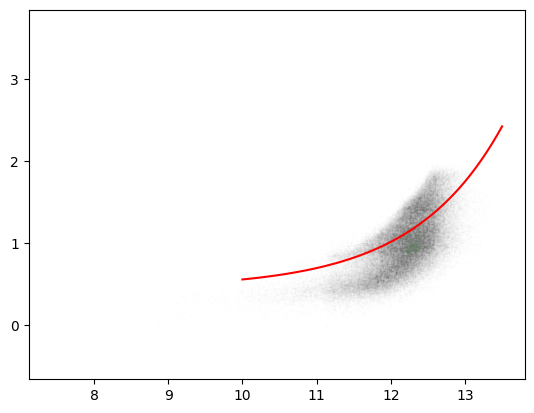

In [8]:
plt.scatter(np.log10(luminosity_r), g-r, s=1, alpha=0.005, color='green')
plt.plot(x, separation_line, color='red')
plt.show()

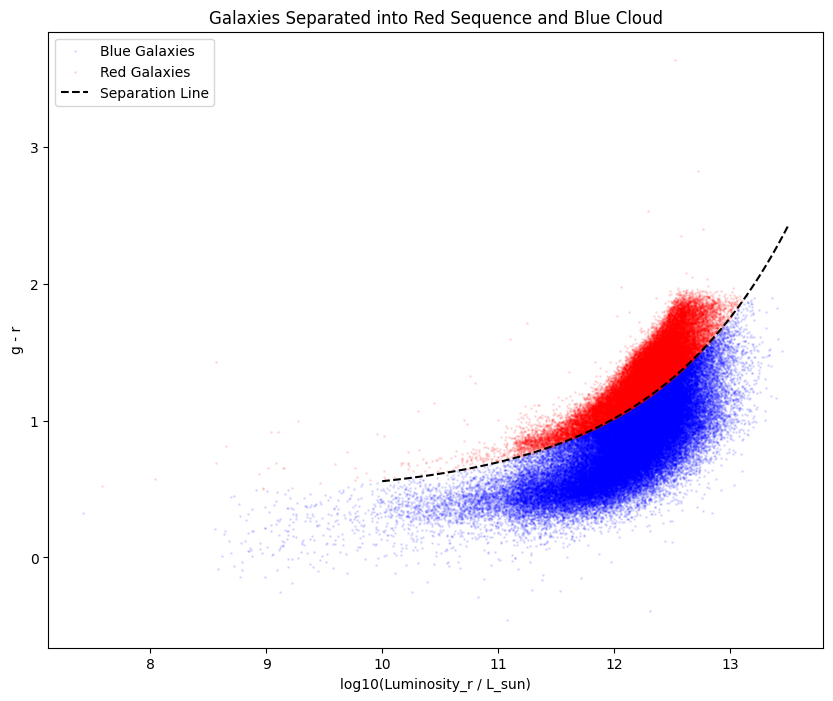

In [9]:
# Calculate the y-value of the separation line for each galaxy's luminosity
separation_values = 1.3 * np.exp((np.log10(luminosity_r) - 13) / 1.2) + 0.45

# Create boolean masks to identify which group each galaxy belongs to
red_sequence_mask = (g - r) <= separation_values
blue_cloud_mask = (g - r) > separation_values

# Plot the two groups with different colors
plt.figure(figsize=(10, 8))
plt.scatter(np.log10(luminosity_r)[red_sequence_mask], (g - r)[red_sequence_mask], s=1, alpha=0.1, color='blue', label='Blue Galaxies')
plt.scatter(np.log10(luminosity_r)[blue_cloud_mask], (g - r)[blue_cloud_mask], s=1, alpha=0.1, color='red', label='Red Galaxies')

# Plot the original separation line for reference
plt.plot(x, separation_line, color='black', linestyle='--', label='Separation Line')

plt.xlabel('log10(Luminosity_r / L_sun)')
plt.ylabel('g - r')
plt.title('Galaxies Separated into Red Sequence and Blue Cloud')
plt.legend()
plt.savefig('./figures/Nov26/color_diagram.png')
plt.show()